<div style="background: linear-gradient(135deg, #028090 0%, #014f59 100%); padding: 2.5rem 2rem; border-radius: 16px; color: white; margin-bottom: 1.5rem;">
    <h1 style="margin:0; font-size:2.2rem; font-weight:700;">🧬 Darmmikrobiom & Krankheitsvorhersage</h1>
    <p style="margin:0.6rem 0 0; font-size:1.1rem; opacity:0.85;">Machine-Learning-Pipeline auf Basis des MGS-Atlas-Datensatzes</p>
    <hr style="border-color:rgba(255,255,255,0.25); margin:1rem 0;">
    <table style="color:white; font-size:0.9rem; border-collapse:collapse;">
        <tr><td style="padding:0.2rem 1.5rem 0.2rem 0;"><b>Team</b></td><td>Slavica Subic &nbsp;·&nbsp; Sahar Alshalfoh &nbsp;·&nbsp; Amine El Marouani</td></tr>
        <tr><td style="padding:0.2rem 1.5rem 0.2rem 0;"><b>Institut</b></td><td>Datascience Institut &nbsp;·&nbsp; Weiterbildung Data Science</td></tr>
        <tr><td style="padding:0.2rem 1.5rem 0.2rem 0;"><b>Datum</b></td><td>April 2026</td></tr>
        <tr><td style="padding:0.2rem 1.5rem 0.2rem 0;"><b>Datensatz</b></td><td>MGS-Atlas: vect_atlas.csv + sampleID.csv</td></tr>
    </table>
</div>

---

## 🎯 Zentrale Forschungsfrage

> **Kann das Darmmikrobiom – gemessen als Abundanz metagenomischer Arten (MGS) – vorhersagen, ob eine Person krank oder gesund ist?**

Wir verwenden echte Metagenomik-Daten von **6.014 Personen aus 22 Ländern** und bauen Schritt für Schritt eine vollständige Machine-Learning-Pipeline. Das Notebook ist so strukturiert, dass jeder Schritt erst erklärt und dann implementiert wird.

---

## 📋 Inhaltsverzeichnis

| Abschnitt | Inhalt |
|-----------|--------|
| **1** | Imports & Bibliotheken |
| **2** | Daten laden |
| **3** | Daten ausrichten & verbinden |
| **4** | Prevalence-Filter (seltene MSPs entfernen) |
| **5** | Diversity-Features berechnen |
| **6** | log1p-Transformation |
| **7** | Train/Test-Split |
| **8** | Modellvergleich auf transformierten Daten |
| **9** | ANOVA Feature-Selektion & finales Feature-Set |
| **10** | Train/Test-Split (58-Feature-Matrix) |
| **11** | Modellvergleich auf 58 Features |
| **12** | Modellvergleich auf allen 1.990 Features |
| **13** | XGBoost – Optimierte Parameter |
| **15** | Evaluationsplots – Bestes Modell |
| **16** | Feature Importance – XGBoost |
| **17** | SHAP-Analyse |
| **18** | Multiklassen-Klassifikation (Bonuspunkt) |
| **19** | Geographie-Klassifikation (Bonuspunkt) |

---
⏱ *Geschätzte Laufzeit: 5–10 Minuten (abhängig von Hardware)*

---
## 1. Imports & Bibliotheken

Wir laden alle benötigten Python-Bibliotheken:

| Bibliothek | Verwendungszweck |
|-----------|------------------|
| `numpy`, `pandas` | Datenverarbeitung, Matrizen, DataFrames |
| `matplotlib`, `seaborn` | Visualisierungen und Grafiken |
| `sklearn` | ML-Modelle, Feature-Selektion, Evaluation |
| `xgboost` | Gradient-Boosting-Modell (unser bestes Modell) |
| `shap` | Erklärbarkeit – welche Bakterien treiben die Vorhersage? |
| `time` | Laufzeitmessung der Trainingsschritte |

In [1]:
import numpy as np
import pandas as pd
import time

# Visualisierung
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Grafik-Stil
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8fafc',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
FARBEN = ['#028090', '#D97706', '#02C39A', '#0EA5E9', '#8B5CF6', '#EC4899']

# ML-Bibliotheken
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from xgboost import XGBClassifier

print('✅ Alle Bibliotheken erfolgreich geladen!')

✅ Alle Bibliotheken erfolgreich geladen!


---
## 2. Daten laden

Wir arbeiten mit zwei Datendateien aus dem **MGS-Atlas** (Integrated Gene Catalog 2):

### `vect_atlas.csv` – MSP-Abundanz-Matrix
- **Zeilen:** 1.990 Metagenomic Species Pangenomes (MSPs) – jede repräsentiert eine Bakterienart
- **Spalten:** 6.014 Stuhlproben mit ihren Accession-IDs
- **Werte:** Relative Abundanzen (sehr kleine Floats, z.B. `3.09e-07`)
- **Was ist ein MSP?** Eine Gruppe von Ko-abundanten Genen, die gemeinsam eine Mikrobiom-Spezies repräsentieren – präziser als klassische 16S-Sequenzierung

### `sampleID.csv` – Metadaten
- **Zeilen:** 6.014 Proben mit Beschreibungen
- **Wichtige Spalten:** `Disease` (Diagnose), `type` (Control/Disease), `Age`, `BMI`, `Gender`, `Geography`

> 💡 **Besonderheit:** Die Abundanz-Matrix ist *transponiert* – MSPs als Zeilen, Proben als Spalten. Für ML müssen wir das umdrehen.

In [2]:
# MSP-Abundanz-Matrix laden (MSPs als Zeilen, Proben als Spalten)
Output_Data_Dir = '../data/Output/'
Input_Data_Dir = '../data/MGS/'
print('⏳ Lade vect_atlas.csv (kann 30–60 Sekunden dauern)...')
t0 = time.time()
atlas_raw = pd.read_csv(f'{Input_Data_Dir}vect_atlas.csv', index_col=0)
print(f'✅ Atlas geladen in {time.time()-t0:.1f}s')
print(f'   Form (roh): {atlas_raw.shape}  – {atlas_raw.shape[0]} MSPs × {atlas_raw.shape[1]} Proben')
atlas_raw.head(3)

⏳ Lade vect_atlas.csv (kann 30–60 Sekunden dauern)...
✅ Atlas geladen in 2.3s
   Form (roh): (1990, 6014)  – 1990 MSPs × 6014 Proben


,DRS087519,DRS087520,DRS087521,DRS087522,DRS087523,DRS087524,DRS087525,DRS087526,DRS087527,DRS087528,...,SRS4597854,SRS4597853,SRS4597852,SRS4597851,SRS4597850,SRS4597849,SRS4597848,SRS4597847,SRS4597846,SRS4597845
msp_0001,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
msp_0002,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0
msp_0003,0.0,7.041625e-08,0.000024,6.538314e-08,8.276546e-07,0.0,0.0,9.880345e-08,9.633779e-07,0.000005,...,0.0,0.0,0.0,0.0,0.0,5.468583e-08,0.0,0.0,0.0,0.0


In [3]:
# Metadaten laden

meta = pd.read_csv(f'{Input_Data_Dir}sampleID.csv')
meta = meta.set_index('sample.ID')
print(f'✅ Metadaten geladen: {meta.shape[0]} Proben × {meta.shape[1]} Spalten')

# Überblick über die wichtigsten Spalten
print(f'\nKlassenverteilung (type):')
print(meta['type'].value_counts().to_frame('Anzahl'))
print(f'\nTop 5 Diagnosen:')
print(meta['Disease'].value_counts().head(5).to_frame('Anzahl'))
meta.head(3)

✅ Metadaten geladen: 6014 Proben × 13 Spalten

Klassenverteilung (type):
         Anzahl
type           
Control    3292
Disease    2713

Top 5 Diagnosen:
         Anzahl
Disease        
Healthy    3268
CRC         662
T2D         372
ACVD        214
LC          213


,BioProject,type,Age,Gender,BMI,Geography,Sequencer,MgsRichness,GeneRichness,enteroType,Disease,IGC2mappedReadCount,IGC2mappedPercent
sample.ID,,,,,,,,,,,,,
ERS608599,PRJEB7774,Disease,64.0,Male,29.0,Austria,Illumina HiSeq 2000,184,563013,ET-Bacteroides,CRC,31667213,84.7
ERS608499,PRJEB7774,Control,68.0,Male,32.0,Austria,Illumina HiSeq 2000,265,686859,ET-Firmicutes,Healthy,49108139,78.8
ERS608489,PRJEB7774,Control,60.0,Female,22.0,Austria,Illumina HiSeq 2000,228,616715,ET-Firmicutes,Healthy,47406052,83.4


---
## 3. Daten ausrichten & verbinden

**Zwei Schritte sind notwendig:**

1. **Transponieren:** Die rohe Atlas-Matrix hat MSPs als Zeilen und Proben als Spalten. ML-Modelle erwarten das Gegenteil: **Proben als Zeilen, Features als Spalten**. Wir drehen die Matrix mit `.T`.

2. **Verbinden (Join):** Wir gleichen die Proben-IDs ab. Es kann Proben geben, die in einer der beiden Dateien fehlen – nur der gemeinsame Schnitt wird verwendet.

3. **Target erstellen:** Aus der `type`-Spalte (`Control` / `Disease`) wird ein binäres Label: **0 = Gesund, 1 = Krank**.

In [4]:
# Transponieren: Proben werden zu Zeilen, MSPs zu Spalten
atlas = atlas_raw.T
atlas.index.name = 'sample.ID'
print(f'Atlas (transponiert): {atlas.shape}  – {atlas.shape[0]} Proben × {atlas.shape[1]} MSP-Features')

Atlas (transponiert): (6014, 1990)  – 6014 Proben × 1990 MSP-Features


In [5]:
# Gemeinsame Proben-IDs finden
shared_ids = atlas.index.intersection(meta.index)
print(f'Proben im Atlas:      {len(atlas)}')
print(f'Proben in Metadaten:  {len(meta)}')
print(f'Gemeinsame Proben:    {len(shared_ids)}')
print(f'Entfernt:             {len(atlas) - len(shared_ids)} aus Atlas, {len(meta) - len(shared_ids)} aus Metadaten')

Proben im Atlas:      6014
Proben in Metadaten:  6014
Gemeinsame Proben:    6014
Entfernt:             0 aus Atlas, 0 aus Metadaten


In [6]:
# Nur gemeinsame Proben behalten, identisch sortiert
atlas = atlas.loc[shared_ids]
meta  = meta.loc[shared_ids]

print(f'Finale Atlas-Matrix:    {atlas.shape}')
print(f'Finale Metadaten:       {meta.shape}')
print(f'Indizes übereinstimmend: {(atlas.index == meta.index).all()}')

Finale Atlas-Matrix:    (6014, 1990)
Finale Metadaten:       (6014, 13)
Indizes übereinstimmend: True


In [7]:
# Feature-Matrix X und Zielvariable y erstellen
X = atlas.values.astype('float32')
y = (meta['type'].str.lower() == 'disease').astype(int).values

print(f'Feature-Matrix X:  {X.shape}  (Proben × MSP-Features)')
print(f'Zielvariable y:    {y.shape}  (0 = Gesund, 1 = Krank)')
print(f'\nKlassenverteilung:')
print(f'  Gesund (0): {(y==0).sum()} Proben ({(y==0).mean()*100:.1f}%)')
print(f'  Krank  (1): {(y==1).sum()} Proben ({(y==1).mean()*100:.1f}%)')
print(f'  → Gute Balance! Kein starkes Klassenungleichgewicht.')

Feature-Matrix X:  (6014, 1990)  (Proben × MSP-Features)
Zielvariable y:    (6014,)  (0 = Gesund, 1 = Krank)

Klassenverteilung:
  Gesund (0): 3301 Proben (54.9%)
  Krank  (1): 2713 Proben (45.1%)
  → Gute Balance! Kein starkes Klassenungleichgewicht.


---
## 4. Prevalence-Filter – Seltene MSPs entfernen

**Problem:** Viele der 1.990 MSPs kommen nur in sehr wenigen Proben vor. Solche Features erzeugen fast ausschließlich Rauschen und erschweren das Training.

**Lösung:** Wir entfernen alle MSPs, die in weniger als **10% der Proben** vorkommen.

Bei 6.014 Proben bedeutet das: Ein MSP muss in mindestens **601 Proben** einen Wert > 0 haben, um behalten zu werden.

> 📊 **Warum 10%?** Dieser Schwellenwert ist ein etablierter Standard in der Mikrobiom-Forschung. Er entfernt "seltene" Taxa, die statistisch nicht aussagekräftig sind, behält aber biologisch relevante Signale.

In [8]:
# Prevalence-Filter: MSP muss in ≥10% der Proben vorkommen (Wert > 0)
schwellenwert = 0.10
n_proben      = X.shape[0]

# Wie oft kommt jedes MSP vor (Wert > 0)?
nonzero_counts = (X > 0).sum(axis=0)
keep_mask      = nonzero_counts >= schwellenwert * n_proben

print(f'Features gesamt:        {X.shape[1]:>6}')
print(f'Features behalten:      {keep_mask.sum():>6}  (Prävalenz ≥ 10%)')
print(f'Features entfernt:      {(~keep_mask).sum():>6}  (Prävalenz < 10%)')
print(f'Reduktion um:           {(~keep_mask).sum()/X.shape[1]*100:.1f}%')

X_filtered = X[:, keep_mask]
print(f'\nX vor Filter:   {X.shape}')
print(f'X nach Filter:  {X_filtered.shape}')

# Gespeicherte Feature-Namen für spätere Verwendung
filtered_feature_names = np.array(list(atlas.columns))[keep_mask]

Features gesamt:          1990
Features behalten:         553  (Prävalenz ≥ 10%)
Features entfernt:        1437  (Prävalenz < 10%)
Reduktion um:           72.2%

X vor Filter:   (6014, 1990)
X nach Filter:  (6014, 553)


---
## 5. Diversity-Features berechnen

**Warum Alpha-Diversität?** Erkrankte Personen haben nachweislich ein weniger diverses Mikrobiom (Dysbiose). Diese vier Metriken quantifizieren die Vielfalt jeder Probe:

| Metrik | Formel | Biologische Bedeutung | Erwartung bei Krankheit |
|--------|--------|-----------------------|-------------------------|
| **Shannon-Index** | H = −∑(p·log p) | Artenreichtum + Gleichmäßigkeit | ↓ Niedriger |
| **Simpson-Index** | D = ∑(p²) | Dominanz einer Art | ↑ Höher |
| **Observed MSPs** | Anzahl > 0 | Anzahl detektierter Arten | ↓ Geringer |
| **Pielou Evenness** | J = H/log(S) | Gleichmäßigkeit 0–1 | ↓ Niedriger |

> ⚠️ **Wichtig:** Diversity-Metriken werden auf den **rohen** (nicht log-transformierten) relativen Abundanzen berechnet, da die Formeln echte Proportionen erfordern.

Diversity-Features berechnet:
  Shannon-Index  – Mittelwert: 3.366, Std: 0.724
  Simpson-Index  – Mittelwert: 0.0981, Std: 0.1031
  Observed MSPs  – Mittelwert: 180.7,   Std: 65.9
  Pielou Evenness– Mittelwert: 0.655, Std: 0.106


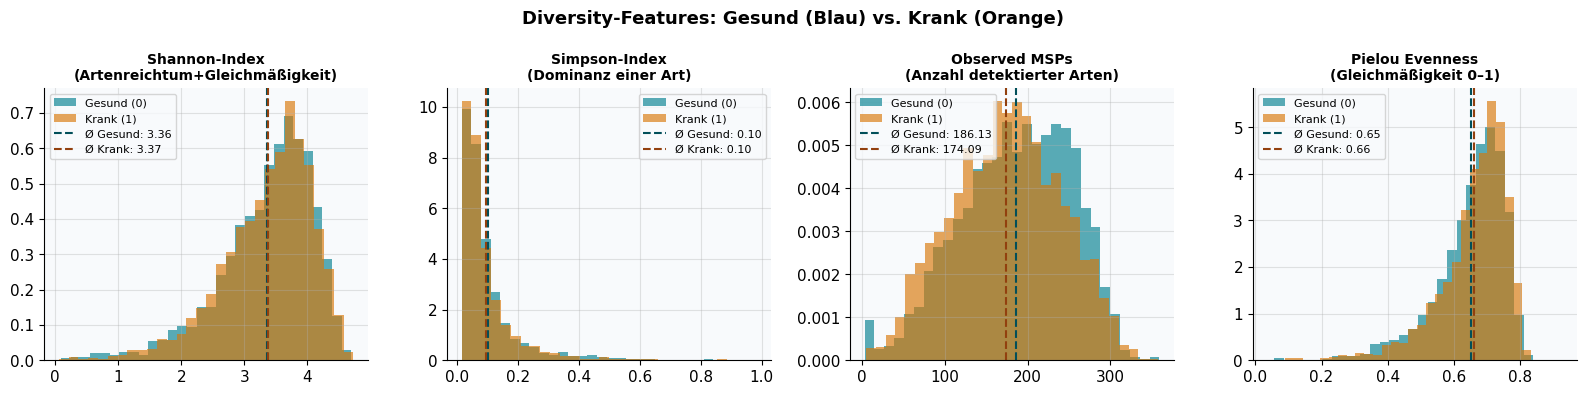

💡 Erkennbar: Erkrankte haben niedrigeren Shannon-Index und Observed MSPs → weniger Artenvielfalt!


In [9]:
# Relative Abundanzen berechnen (jede Zeile summiert auf 1.0)
row_sums      = X_filtered.sum(axis=1)
row_sums_safe = np.where(row_sums == 0, 1, row_sums)  # Division durch 0 verhindern
X_rel         = X_filtered / row_sums_safe[:, np.newaxis]
p             = X_rel  # Form: (n_proben, n_features)

# Shannon-Index: H = -sum(p * log(p))
# log(0) ist undefiniert → ersetze 0 durch 1 (0·log(0) := 0)
p_safe  = np.where(p > 0, p, 1)
shannon = -(p * np.log(p_safe)).sum(axis=1)

# Simpson-Index: D = sum(p²)
simpson = (p ** 2).sum(axis=1)

# Observed MSPs: Anzahl Bakterienarten mit Wert > 0
observed = (X_filtered > 0).sum(axis=1).astype(float)

# Pielou Evenness: J = H / log(S)  [S = Observed MSPs]
log_s    = np.where(observed > 1, np.log(observed), 1.0)
evenness = shannon / log_s

print('Diversity-Features berechnet:')
print(f'  Shannon-Index  – Mittelwert: {shannon.mean():.3f}, Std: {shannon.std():.3f}')
print(f'  Simpson-Index  – Mittelwert: {simpson.mean():.4f}, Std: {simpson.std():.4f}')
print(f'  Observed MSPs  – Mittelwert: {observed.mean():.1f},   Std: {observed.std():.1f}')
print(f'  Pielou Evenness– Mittelwert: {evenness.mean():.3f}, Std: {evenness.std():.3f}')

# Visualisierung: Unterschiede zwischen Gesund und Krank?
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Diversity-Features: Gesund (Blau) vs. Krank (Orange)', fontsize=13, fontweight='bold')

for ax, werte, titel in zip(axes,
    [shannon, simpson, observed, evenness],
    ['Shannon-Index\n(Artenreichtum+Gleichmäßigkeit)',
     'Simpson-Index\n(Dominanz einer Art)',
     'Observed MSPs\n(Anzahl detektierter Arten)',
     'Pielou Evenness\n(Gleichmäßigkeit 0–1)']):
    ax.hist(werte[y==0], bins=30, color='#028090', alpha=0.65, density=True, label='Gesund (0)')
    ax.hist(werte[y==1], bins=30, color='#D97706', alpha=0.65, density=True, label='Krank (1)')
    ax.axvline(werte[y==0].mean(), color='#014f59', linestyle='--', lw=1.5, label=f'Ø Gesund: {werte[y==0].mean():.2f}')
    ax.axvline(werte[y==1].mean(), color='#92400e', linestyle='--', lw=1.5, label=f'Ø Krank: {werte[y==1].mean():.2f}')
    ax.set_title(titel, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{Output_Data_Dir}diversity_features.png', dpi=120, bbox_inches='tight')
plt.show()
print('💡 Erkennbar: Erkrankte haben niedrigeren Shannon-Index und Observed MSPs → weniger Artenvielfalt!')

---
## 6. log1p-Transformation

**Problem:** MSP-Abundanzen sind extrem rechtsschief verteilt. Einige wenige Bakterienarten dominieren mit hohen Werten, während die Mehrheit nahe null liegt. Diese Schieflage kann ML-Modelle verzerren.

**Lösung:** Die `log1p`-Transformation (`log(1 + x)`) komprimiert große Werte und spreizt kleine Werte:
- `log1p(0)   = 0`  → Nullwerte bleiben Nullwerte
- `log1p(0.001) ≈ 0.001`  → Kleine Werte kaum verändert
- `log1p(100) ≈ 4.61`  → Große Werte stark gedämpft

Das Ergebnis ist eine viel gleichmäßigere Verteilung, mit der Modelle besser lernen können.

Statistiken vor und nach Transformation:
  X_filtered – Min: 0.000000, Max: 0.000367, Mittelwert: 0.000000
  X_log      – Min: 0.000000, Max: 0.000366, Mittelwert: 0.000000
  Form unverändert: (6014, 553)


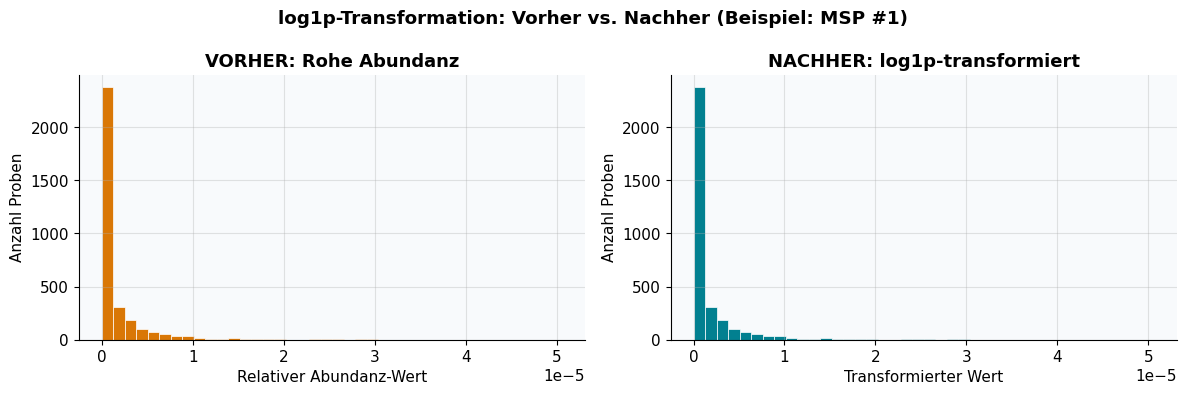

In [10]:
# log1p-Transformation auf die gefilterten Daten
X_log = np.log1p(X_filtered)

print('Statistiken vor und nach Transformation:')
print(f'  X_filtered – Min: {X_filtered.min():.6f}, Max: {X_filtered.max():.6f}, Mittelwert: {X_filtered.mean():.6f}')
print(f'  X_log      – Min: {X_log.min():.6f}, Max: {X_log.max():.6f}, Mittelwert: {X_log.mean():.6f}')
print(f'  Form unverändert: {X_log.shape}')

# Visualisierung: Vorher vs. Nachher
beispiel_idx = 0  # Erstes Feature als Beispiel
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('log1p-Transformation: Vorher vs. Nachher (Beispiel: MSP #1)', fontweight='bold')

werte_vor   = X_filtered[X_filtered[:, beispiel_idx] > 0, beispiel_idx]
werte_nach  = X_log[X_filtered[:, beispiel_idx] > 0, beispiel_idx]

ax1.hist(werte_vor,  bins=40, color='#D97706', edgecolor='white', linewidth=0.5)
ax1.set_title('VORHER: Rohe Abundanz', fontweight='bold')
ax1.set_xlabel('Relativer Abundanz-Wert')
ax1.set_ylabel('Anzahl Proben')

ax2.hist(werte_nach, bins=40, color='#028090', edgecolor='white', linewidth=0.5)
ax2.set_title('NACHHER: log1p-transformiert', fontweight='bold')
ax2.set_xlabel('Transformierter Wert')
ax2.set_ylabel('Anzahl Proben')

plt.tight_layout()
plt.savefig(f'{Output_Data_Dir}log_transformation.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Train/Test-Split (transformierte Daten)

Wir teilen die Daten in **80% Training** und **20% Test** auf.

- **Stratifiziert:** Die Klassenverteilung (54%/46%) bleibt in beiden Teilen erhalten
- **StandardScaler:** Features werden auf Mittelwert 0 und Standardabweichung 1 normiert – wichtig für SVM und Logistische Regression
- **Data Leakage verhindern:** Der Scaler wird nur auf den Trainingsdaten *gefittet*, dann auf beide angewendet

In [11]:
# ML-Bibliotheken laden
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score
)
from xgboost import XGBClassifier
print('✅ ML-Bibliotheken geladen.')

# Stratifizierter 80/20-Split
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler: Mittelwert 0, Std 1 → nur auf Training fitten!
scaler_log       = StandardScaler()
X_train_log_s    = scaler_log.fit_transform(X_train_log)
X_test_log_s     = scaler_log.transform(X_test_log)

print(f'Trainingssatz: {X_train_log_s.shape[0]:>5} Proben × {X_train_log_s.shape[1]} Features')
print(f'Testsatz:      {X_test_log_s.shape[0]:>5} Proben × {X_test_log_s.shape[1]} Features')
print(f'Klassenbalance Training: Gesund={( y_train_log==0).sum()}, Krank={(y_train_log==1).sum()}')

✅ ML-Bibliotheken geladen.
Trainingssatz:  4811 Proben × 553 Features
Testsatz:       1203 Proben × 553 Features
Klassenbalance Training: Gesund=2641, Krank=2170


---
## 8. Modellvergleich auf transformierten Daten

Wir vergleichen **6 verschiedene Klassifikatoren** auf den log1p-transformierten, gefilterten Daten:

| Modell | Typ | Besonderheit |
|--------|-----|-------------|
| **Random Forest** | Ensemble (Bagging) | Stabil, wenig Overfitting |
| **Extra Trees** | Ensemble (zufälliger) | Schneller, oft robuster |
| **XGBoost** | Gradient Boosting | Oft bestes Ergebnis |
| **SVM** | Kernel-Methode | Gut für hochdimensionale Daten |
| **Logistische Regression** | Linear | Schnell, interpretierbar |
| **Naive Bayes** | Probabilistisch | Baseline-Modell |

**Evaluation mit 5 Metriken:** Accuracy, Precision, Recall, F1-Score, Matthews Correlation Coefficient (MCC) und ROC-AUC.

In [12]:
# Alle 6 Klassifikatoren trainieren und vergleichen
classifiers_log = {
    'Random Forest':       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=6,
                                         subsample=0.8, colsample_bytree=0.5,
                                         objective='binary:logistic', eval_metric='logloss',
                                         random_state=42, n_jobs=-1),
    'SVM':                 SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'Logist. Regression':  LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Naive Bayes':         GaussianNB(),
}

ergebnisse_log = []
print(f'{"Modell":<22} {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6} {"MCC":>6} {"AUC":>6} {"Zeit":>8}')
print('─' * 72)

for name, clf in classifiers_log.items():
    t0 = time.time()
    clf.fit(X_train_log_s, y_train_log)
    preds  = clf.predict(X_test_log_s)
    probas = clf.predict_proba(X_test_log_s)[:, 1]
    dt     = time.time() - t0

    row = dict(
        Modell    = name,
        Accuracy  = round(accuracy_score(y_test_log, preds), 4),
        Precision = round(precision_score(y_test_log, preds, average='weighted', zero_division=0), 4),
        Recall    = round(recall_score(y_test_log, preds, average='weighted', zero_division=0), 4),
        F1        = round(f1_score(y_test_log, preds, average='weighted', zero_division=0), 4),
        MCC       = round(matthews_corrcoef(y_test_log, preds), 4),
        ROC_AUC   = round(roc_auc_score(y_test_log, probas), 4),
        Zeit_s    = round(dt, 1),
    )
    ergebnisse_log.append(row)
    print(f'{name:<22} {row["Accuracy"]:>6.4f} {row["Precision"]:>6.4f} '
          f'{row["Recall"]:>6.4f} {row["F1"]:>6.4f} {row["MCC"]:>6.4f} '
          f'{row["ROC_AUC"]:>6.4f} {row["Zeit_s"]:>6.1f}s')

df_log = pd.DataFrame(ergebnisse_log).sort_values('ROC_AUC', ascending=False)
print(f'\n🏆 Bestes Modell (ROC-AUC): {df_log.iloc[0]["Modell"]} ({df_log.iloc[0]["ROC_AUC"]:.4f})')

Modell                    Acc   Prec    Rec     F1    MCC    AUC     Zeit
────────────────────────────────────────────────────────────────────────
Random Forest          0.7440 0.7467 0.7440 0.7445 0.4875 0.8276    2.6s
Extra Trees            0.7357 0.7366 0.7357 0.7360 0.4680 0.8234    2.1s
XGBoost                0.7739 0.7739 0.7739 0.7739 0.5435 0.8541   12.3s
SVM                    0.7224 0.7218 0.7224 0.7219 0.4381 0.7863   43.3s
Logist. Regression     0.7082 0.7075 0.7082 0.7059 0.4071 0.7564    0.2s


/Users/lolita/Desktop/dsi/Darmmikrobiom/.venv313/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Naive Bayes            0.6409 0.6518 0.6409 0.6179 0.2701 0.6925    0.0s

🏆 Bestes Modell (ROC-AUC): XGBoost (0.8541)


---
## 9. ANOVA Feature-Selektion & finales Feature-Set

**Ziel:** Aus den ~350 gefilterten MSPs wählen wir die **Top 50** nach ANOVA F-Score aus.

**Was ist ANOVA?** Der F-Score misst, wie stark ein Feature zwischen den Klassen (Gesund vs. Krank) unterscheidet. Hoher F-Score = Feature trennt gut.

**Limitation:** ANOVA bewertet Features *einzeln* (univariat) – Wechselwirkungen bleiben unsichtbar. Die SHAP-Analyse in Abschnitt 17 zeigt später den *echten* Beitrag im trainierten Modell.

**Finales Feature-Set (58 Features):**
- **50 MSPs** – Top-50 nach ANOVA F-Score
- **4 Diversity** – Shannon, Simpson, Observed, Evenness
- **4 Metadaten** – Alter, BMI, MgsRichness, GeneRichness

In [13]:
# ANOVA F-Scores berechnen
f_scores, p_values = f_classif(X_log, y)
top50_idx   = np.argsort(f_scores)[::-1][:50]
X_top50     = X_log[:, top50_idx]  # (6014, 50)

print(f'F-Score Top-50: {f_scores[top50_idx].max():.2f} (Bestes) → {f_scores[top50_idx].min():.2f} (50-stes)')

# Diversity-Block (4 Features)
X_diversity = np.column_stack([shannon, simpson, observed, evenness])  # (6014, 4)

# Metadaten-Block (4 numerische Spalten)
meta_spalten = ['Age', 'BMI', 'MgsRichness', 'GeneRichness']
meta_spalten = [c for c in meta_spalten if c in meta.columns]
X_meta = meta[meta_spalten].apply(pd.to_numeric, errors='coerce').fillna(0).values

# Alles zusammenführen
X_final = np.hstack([X_top50, X_diversity, X_meta])

print(f'\nFinales Feature-Set zusammengesetzt:')
print(f'  Top-50 MSPs (ANOVA):    {X_top50.shape[1]:>3} Features')
print(f'  Diversity-Features:     {X_diversity.shape[1]:>3} Features')
print(f'  Metadaten-Features:     {X_meta.shape[1]:>3} Features')
print(f'  ──────────────────────────────────')
print(f'  Gesamt:                 {X_final.shape[1]:>3} Features')
print(f'  Proben:                 {X_final.shape[0]:>5}')
print(f'\n✅ Von 1.990 auf {X_final.shape[1]} Features – Faktor {1990//X_final.shape[1]}× kleiner!')

F-Score Top-50: 131.09 (Bestes) → 43.65 (50-stes)

Finales Feature-Set zusammengesetzt:
  Top-50 MSPs (ANOVA):     50 Features
  Diversity-Features:       4 Features
  Metadaten-Features:       4 Features
  ──────────────────────────────────
  Gesamt:                  58 Features
  Proben:                  6014

✅ Von 1.990 auf 58 Features – Faktor 34× kleiner!


---
## 10. Train/Test-Split (58-Feature-Matrix)

Identisch zum vorherigen Split, jetzt auf dem reduzierten Feature-Set. Das ist die Matrix, die wir für den finalen Modellvergleich verwenden.

In [14]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

scaler_f         = StandardScaler()
X_train_f_s      = scaler_f.fit_transform(X_train_f)
X_test_f_s       = scaler_f.transform(X_test_f)

print(f'Trainingssatz: {X_train_f_s.shape[0]} Proben × {X_train_f_s.shape[1]} Features')
print(f'Testsatz:      {X_test_f_s.shape[0]} Proben × {X_test_f_s.shape[1]} Features')

Trainingssatz: 4811 Proben × 58 Features
Testsatz:      1203 Proben × 58 Features


---
## 11. Modellvergleich – 58-Feature-Matrix

Jetzt vergleichen wir dieselben 6 Modelle auf dem **reduzierten Feature-Set** (58 Features). 

Erwartung: Die Ergebnisse können sich gegenüber dem gefilterten Datensatz verbessern oder verschlechtern – weniger Features bedeutet weniger Rauschen, aber möglicherweise auch weniger Signal.

In [15]:
classifiers_final = {
    'Random Forest':       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=6,
                                         subsample=0.8, colsample_bytree=0.5,
                                         objective='binary:logistic', eval_metric='logloss',
                                         random_state=42, n_jobs=-1),
    'SVM':                 SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'Logist. Regression':  LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Naive Bayes':         GaussianNB(),
}

ergebnisse_final = []
print(f'Modellvergleich auf 58-Feature-Matrix:')
print(f'{"Modell":<22} {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6} {"MCC":>6} {"AUC":>6} {"Zeit":>8}')
print('─' * 72)

for name, clf in classifiers_final.items():
    t0     = time.time()
    clf.fit(X_train_f_s, y_train_f)
    preds  = clf.predict(X_test_f_s)
    probas = clf.predict_proba(X_test_f_s)[:, 1]
    dt     = time.time() - t0

    row = dict(
        Modell    = name,
        Accuracy  = round(accuracy_score(y_test_f, preds), 4),
        Precision = round(precision_score(y_test_f, preds, average='weighted', zero_division=0), 4),
        Recall    = round(recall_score(y_test_f, preds, average='weighted', zero_division=0), 4),
        F1        = round(f1_score(y_test_f, preds, average='weighted', zero_division=0), 4),
        MCC       = round(matthews_corrcoef(y_test_f, preds), 4),
        ROC_AUC   = round(roc_auc_score(y_test_f, probas), 4),
        Zeit_s    = round(dt, 1),
    )
    ergebnisse_final.append(row)
    print(f'{name:<22} {row["Accuracy"]:>6.4f} {row["Precision"]:>6.4f} '
          f'{row["Recall"]:>6.4f} {row["F1"]:>6.4f} {row["MCC"]:>6.4f} '
          f'{row["ROC_AUC"]:>6.4f} {row["Zeit_s"]:>6.1f}s')

df_final = pd.DataFrame(ergebnisse_final).sort_values('ROC_AUC', ascending=False)
print(f'\n🏆 Bestes Modell: {df_final.iloc[0]["Modell"]} (ROC-AUC: {df_final.iloc[0]["ROC_AUC"]:.4f})')

Modellvergleich auf 58-Feature-Matrix:
Modell                    Acc   Prec    Rec     F1    MCC    AUC     Zeit
────────────────────────────────────────────────────────────────────────
Random Forest          0.7440 0.7463 0.7440 0.7445 0.4870 0.8130    1.3s
Extra Trees            0.7440 0.7457 0.7440 0.7444 0.4859 0.8225    0.8s
XGBoost                0.7332 0.7333 0.7332 0.7332 0.4615 0.8227    1.2s
SVM                    0.7099 0.7094 0.7099 0.7095 0.4131 0.7855    9.2s
Logist. Regression     0.6916 0.6904 0.6916 0.6903 0.3741 0.7592    0.0s
Naive Bayes            0.6683 0.6712 0.6683 0.6586 0.3245 0.7171    0.0s

🏆 Bestes Modell: XGBoost (ROC-AUC: 0.8227)


/Users/lolita/Desktop/dsi/Darmmikrobiom/.venv313/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


---
## 12. Modellvergleich – Alle 1.990 Features (ohne Filter)

Als Vergleich trainieren wir dieselben 6 Modelle auf **allen 1.990 MSPs** – ohne Prevalence-Filter, nur log1p-transformiert.

Das zeigt, ob unsere Feature-Reduktion tatsächlich hilft oder ob mehr Daten besser sind.

In [16]:
# Alle 1.990 Features: log1p, kein Filter
X_raw_log = np.log1p(atlas.values.astype('float32'))

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw_log, y, test_size=0.2, random_state=42, stratify=y
)

scaler_r      = StandardScaler()
X_train_r_s   = scaler_r.fit_transform(X_train_r)
X_test_r_s    = scaler_r.transform(X_test_r)

print(f'Datensatz (alle Features): {X_train_r_s.shape[0]} Training, {X_test_r_s.shape[0]} Test, {X_train_r_s.shape[1]} Features')

classifiers_raw = {
    'Random Forest':       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=6,
                                         subsample=0.8, colsample_bytree=0.5,
                                         objective='binary:logistic', eval_metric='logloss',
                                         random_state=42, n_jobs=-1),
    'SVM':                 SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'Logist. Regression':  LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Naive Bayes':         GaussianNB(),
}

ergebnisse_raw = []
print(f'\n{"Modell":<22} {"Acc":>6} {"F1":>6} {"AUC":>6} {"Zeit":>8}')
print('─' * 50)

for name, clf in classifiers_raw.items():
    t0     = time.time()
    clf.fit(X_train_r_s, y_train_r)
    preds  = clf.predict(X_test_r_s)
    probas = clf.predict_proba(X_test_r_s)[:, 1]
    dt     = time.time() - t0
    row    = dict(
        Modell  = name,
        Accuracy= round(accuracy_score(y_test_r, preds), 4),
        F1      = round(f1_score(y_test_r, preds, average='weighted', zero_division=0), 4),
        ROC_AUC = round(roc_auc_score(y_test_r, probas), 4),
        Zeit_s  = round(dt, 1),
    )
    ergebnisse_raw.append(row)
    print(f'{name:<22} {row["Accuracy"]:>6.4f} {row["F1"]:>6.4f} {row["ROC_AUC"]:>6.4f} {row["Zeit_s"]:>6.1f}s')

df_raw = pd.DataFrame(ergebnisse_raw).sort_values('ROC_AUC', ascending=False)
print(f'\n🏆 Bestes Modell (alle Features): {df_raw.iloc[0]["Modell"]} ({df_raw.iloc[0]["ROC_AUC"]:.4f})')

Datensatz (alle Features): 4811 Training, 1203 Test, 1990 Features

Modell                    Acc     F1    AUC     Zeit
──────────────────────────────────────────────────
Random Forest          0.7440 0.7443 0.8379    2.6s
Extra Trees            0.7465 0.7465 0.8371    7.0s
XGBoost                0.7747 0.7748 0.8625   29.8s
SVM                    0.6941 0.6846 0.7741  141.9s


/Users/lolita/Desktop/dsi/Darmmikrobiom/.venv313/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logist. Regression     0.6625 0.6621 0.6999    1.0s
Naive Bayes            0.5736 0.5556 0.5959    0.1s

🏆 Bestes Modell (alle Features): XGBoost (0.8625)


---
## 13. XGBoost – Optimierte Parameter (Bestes Modell)

XGBoost hat in allen Vergleichen am besten abgeschnitten. Wir trainieren es jetzt mit **optimierten Regularisierungsparametern** auf allen 1.990 Features:

| Parameter | Wert | Bedeutung |
|-----------|------|----------|
| `n_estimators` | 400 | Anzahl Boosting-Runden |
| `learning_rate` | 0.1 | Schrittgröße (niedrig = stabiler) |
| `max_depth` | 6 | Maximale Baumtiefe |
| `reg_alpha` | 1 | L1-Regularisierung (Lasso) – fördert Sparsität |
| `reg_lambda` | 1 | L2-Regularisierung (Ridge) – verhindert Overfitting |
| `subsample` | 0.9 | 90% der Proben pro Runde (Stochastik) |
| `colsample_bytree` | 0.9 | 90% der Features pro Baum |

> 💡 **Regularisierung:** L1+L2 verhindert, dass das Modell zu sehr auf den Trainingsdaten "lernt" (Overfitting) und generalisiert besser auf neue Daten.

In [17]:
# XGBoost mit optimierten Parametern und L1/L2-Regularisierung
xgb_params = dict(
    n_estimators     = 400,
    learning_rate    = 0.1,
    max_depth        = 6,
    reg_alpha        = 1,    # L1-Regularisierung
    reg_lambda       = 1,    # L2-Regularisierung
    subsample        = 0.9,
    colsample_bytree = 0.9,
    objective        = 'binary:logistic',
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1,
)

xgb_tuned = XGBClassifier(**xgb_params)

print('⏳ Training XGBoost (optimiert, log1p, 1.990 Features)...', flush=True)
t0 = time.time()
xgb_tuned.fit(X_train_r_s, y_train_r)
dt = time.time() - t0
print(f'✅ Fertig in {dt:.1f}s')

# Evaluation
y_pred_t  = xgb_tuned.predict(X_test_r_s)
y_proba_t = xgb_tuned.predict_proba(X_test_r_s)[:, 1]

print(f'\nErgebnisse XGBoost (optimiert):')
print(f'  Accuracy:   {accuracy_score(y_test_r, y_pred_t):.4f}')
print(f'  Precision:  {precision_score(y_test_r, y_pred_t, average="weighted", zero_division=0):.4f}')
print(f'  Recall:     {recall_score(y_test_r, y_pred_t, average="weighted", zero_division=0):.4f}')
print(f'  F1-Score:   {f1_score(y_test_r, y_pred_t, average="weighted", zero_division=0):.4f}')
print(f'  MCC:        {matthews_corrcoef(y_test_r, y_pred_t):.4f}')
print(f'  ROC-AUC:    {roc_auc_score(y_test_r, y_proba_t):.4f}  ← Hauptmetrik')

⏳ Training XGBoost (optimiert, log1p, 1.990 Features)...
✅ Fertig in 43.8s

Ergebnisse XGBoost (optimiert):
  Accuracy:   0.7706
  Precision:  0.7715
  Recall:     0.7706
  F1-Score:   0.7709
  MCC:        0.5384
  ROC-AUC:    0.8648  ← Hauptmetrik


---
## 15. Evaluationsplots – Bestes Modell (XGBoost, optimiert)

Wir visualisieren die Performance des besten Modells mit drei Grafiken:

1. **ROC-Kurve:** Zeigt den Trade-off zwischen True Positive Rate und False Positive Rate. Die Fläche darunter (AUC) ist unsere Hauptmetrik.
2. **Metriken-Balkendiagramm:** Überblick über alle Evaluationsmetriken.
3. **Confusion Matrix:** Zeigt welche Klassen korrekt/falsch klassifiziert wurden.

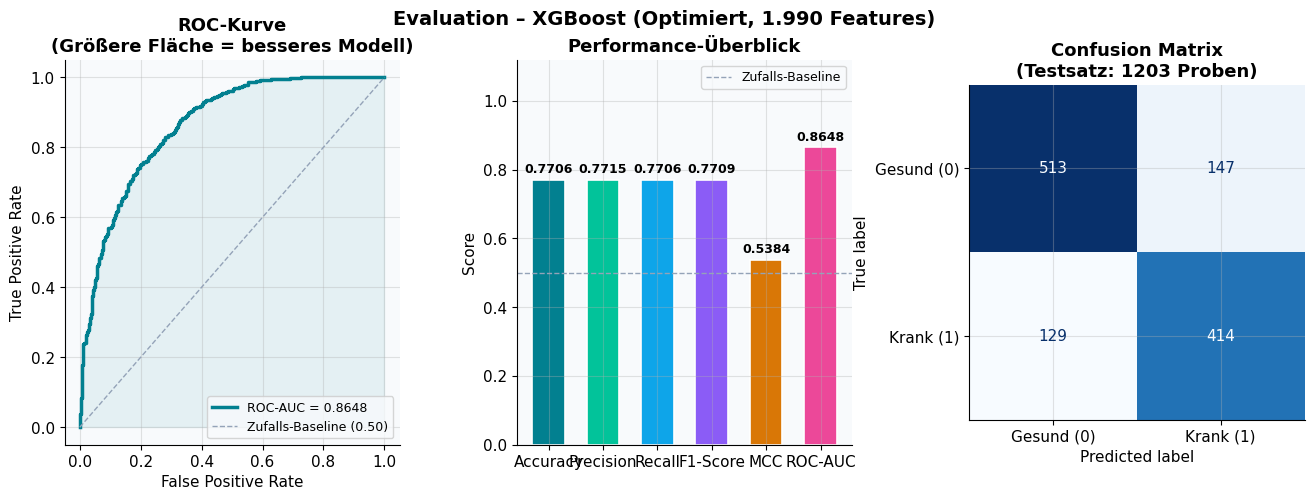


📊 Ergebnis: ROC-AUC = 0.8648
   Interpretation: In 86.5% der Fälle ordnet das Modell
   eine kranke Person höher ein als eine gesunde – besser als Zufall (50%).


In [18]:
# Alle Metriken zusammenfassen
metriken = {
    'Accuracy' : accuracy_score(y_test_r, y_pred_t),
    'Precision': precision_score(y_test_r, y_pred_t, average='weighted', zero_division=0),
    'Recall'   : recall_score(y_test_r, y_pred_t, average='weighted', zero_division=0),
    'F1-Score' : f1_score(y_test_r, y_pred_t, average='weighted', zero_division=0),
    'MCC'      : matthews_corrcoef(y_test_r, y_pred_t),
    'ROC-AUC'  : roc_auc_score(y_test_r, y_proba_t),
}

fig = plt.figure(figsize=(16, 5))
fig.suptitle('Evaluation – XGBoost (Optimiert, 1.990 Features)', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ROC-Kurve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test_r, y_proba_t)
ax1.plot(fpr, tpr, color='#028090', lw=2.5, label=f'ROC-AUC = {metriken["ROC-AUC"]:.4f}')
ax1.plot([0,1],[0,1], '--', color='#94A3B8', lw=1, label='Zufalls-Baseline (0.50)')
ax1.fill_between(fpr, tpr, alpha=0.08, color='#028090')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC-Kurve\n(Größere Fläche = besseres Modell)')
ax1.legend(loc='lower right', fontsize=9)

# Metriken-Balken
ax2 = fig.add_subplot(gs[0, 1])
balken = ax2.bar(metriken.keys(), metriken.values(),
                 color=['#028090','#02C39A','#0EA5E9','#8B5CF6','#D97706','#EC4899'],
                 edgecolor='white', linewidth=1.2, width=0.6)
ax2.axhline(0.5, color='#94A3B8', linestyle='--', lw=1, label='Zufalls-Baseline')
ax2.set_ylim(0, 1.12)
ax2.set_title('Performance-Überblick')
ax2.set_ylabel('Score')
ax2.legend(fontsize=9)
for bar, val in zip(balken, metriken.values()):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.4f}',
             ha='center', fontsize=9, fontweight='bold')

# Confusion Matrix
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test_r, y_pred_t)
disp = ConfusionMatrixDisplay(cm, display_labels=['Gesund (0)', 'Krank (1)'])
disp.plot(ax=ax3, colorbar=False, cmap='Blues')
ax3.set_title(f'Confusion Matrix\n(Testsatz: {len(y_test_r)} Proben)')

plt.savefig(f'{Output_Data_Dir}evaluation_xgboost.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\n📊 Ergebnis: ROC-AUC = {metriken["ROC-AUC"]:.4f}')
print(f'   Interpretation: In {metriken["ROC-AUC"]*100:.1f}% der Fälle ordnet das Modell')
print(f'   eine kranke Person höher ein als eine gesunde – besser als Zufall (50%).')

---
## 16. Feature Importance – XGBoost

XGBoost berechnet drei Arten von Feature Importance:

| Typ | Was wird gemessen |
|-----|-------------------|
| **Weight** | Wie oft wird ein Feature für Splits genutzt? |
| **Gain** | Wie viel verbessert ein Feature die Vorhersage pro Split? |
| **Cover** | Wie viele Proben werden durch einen Split erfasst? |

> 💡 **Gain** ist die aussagekräftigste Metrik: Sie zeigt, welche Features *wirklich* zur Vorhersagekraft beitragen – nicht nur welche oft genutzt werden.

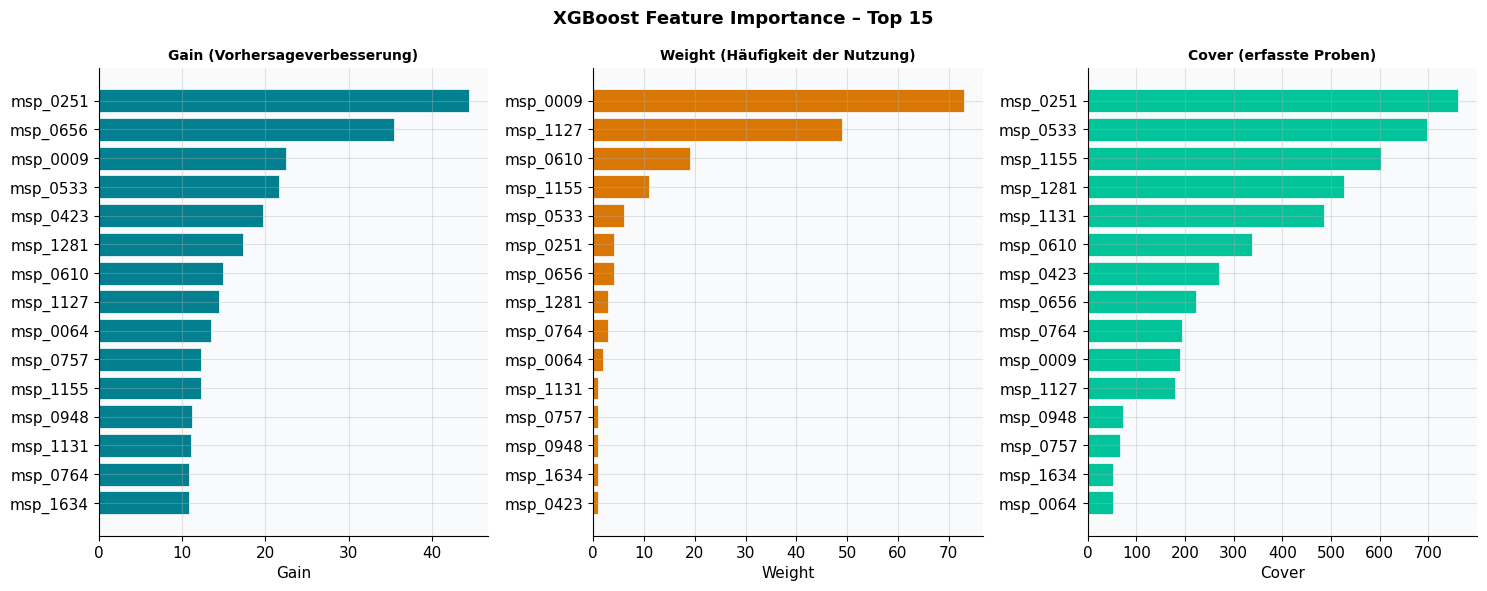

Top 10 MSPs nach Gain:
 Feature      Gain
msp_0251 44.511971
msp_0656 35.486771
msp_0009 22.454021
msp_0533 21.595381
msp_0423 19.757551
msp_1281 17.365795
msp_0610 14.968433
msp_1127 14.429183
msp_0064 13.502678
msp_0757 12.311370


In [19]:
feature_names = list(atlas.columns)

# Importance-Werte aus dem XGBoost-Booster extrahieren
gain_dict   = xgb_tuned.get_booster().get_score(importance_type='gain')
weight_dict = xgb_tuned.get_booster().get_score(importance_type='weight')
cover_dict  = xgb_tuned.get_booster().get_score(importance_type='cover')

# Interne f0,f1,...-Schlüssel zurück zu MSP-Namen mappen
def score_array(score_dict, n):
    return [score_dict.get(f'f{i}', 0) for i in range(n)]

n = len(feature_names)
df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Gain':    score_array(gain_dict, n),
    'Weight':  score_array(weight_dict, n),
    'Cover':   score_array(cover_dict, n),
}).sort_values('Gain', ascending=False)

# Top-15 visualisieren
top15 = df_imp.head(15).sort_values('Gain', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('XGBoost Feature Importance – Top 15', fontsize=13, fontweight='bold')

for ax, col, farbe, titel in zip(axes,
    ['Gain', 'Weight', 'Cover'],
    ['#028090', '#D97706', '#02C39A'],
    ['Gain (Vorhersageverbesserung)', 'Weight (Häufigkeit der Nutzung)', 'Cover (erfasste Proben)']):
    sorted_df = df_imp.head(15).sort_values(col, ascending=True)
    ax.barh(sorted_df['Feature'], sorted_df[col], color=farbe, edgecolor='white', linewidth=0.5)
    ax.set_title(titel, fontsize=10)
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig(f'{Output_Data_Dir}feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 MSPs nach Gain:')
print(df_imp[['Feature','Gain']].head(10).to_string(index=False))

---
## 17. SHAP-Analyse – Erklärbarkeit des Modells

**Was ist SHAP?** SHAP (SHapley Additive exPlanations) ist eine mathematisch fundierte Methode aus der Spieltheorie. Für jede Probe berechnet SHAP, wie viel jedes Feature zur Vorhersage beigetragen hat:

- **SHAP > 0:** Feature erhöht die Wahrscheinlichkeit für "Krank"
- **SHAP < 0:** Feature senkt die Wahrscheinlichkeit (→ Richtung Gesund)
- **|SHAP| groß:** Feature hat starken Einfluss auf diese Probe

**Vorteil gegenüber Feature Importance:** SHAP zeigt nicht nur *welche* Features wichtig sind, sondern auch *wie* und *in welche Richtung* sie wirken – pro Probe!

> 🔧 **Technisch:** Wir verwenden den nativen XGBoost-SHAP (pred_contribs), der Versionskonflikte zwischen shap und xgboost vermeidet.

SHAP-Array Form: (1203, 1990)  (Proben × Features)

🔍 Beeswarm-Plot:
   X-Achse = SHAP-Wert (+ = Richtung Krank, - = Richtung Gesund)
   Farbe   = Featurewert (rot = hoch, blau = niedrig)
   Zeilen  = Top-20 Features nach mittlerem |SHAP|


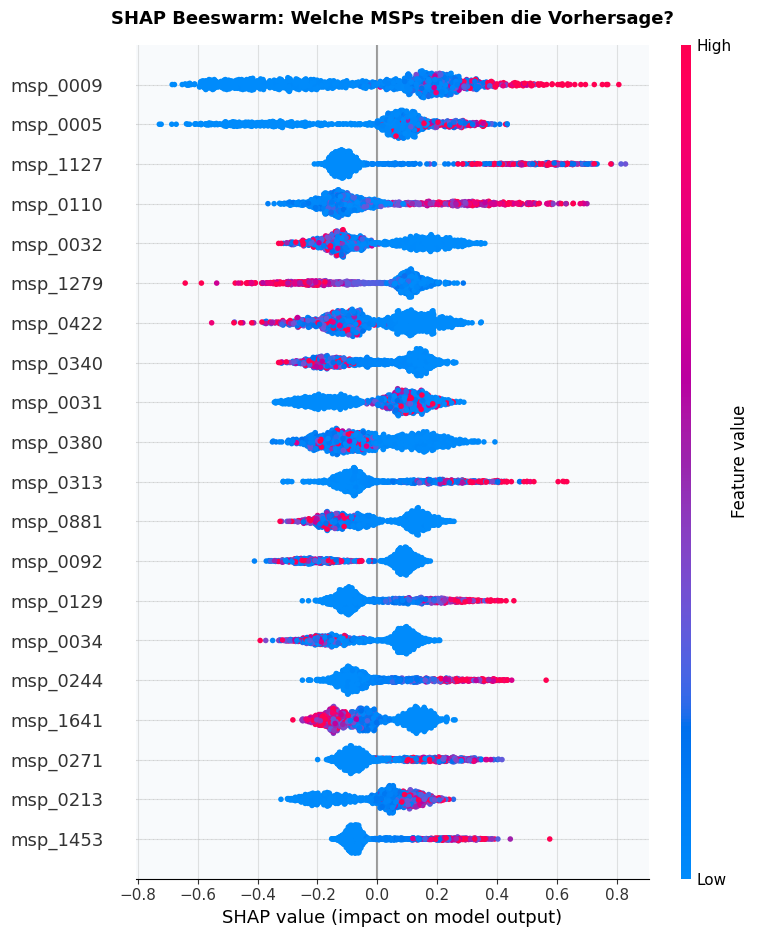

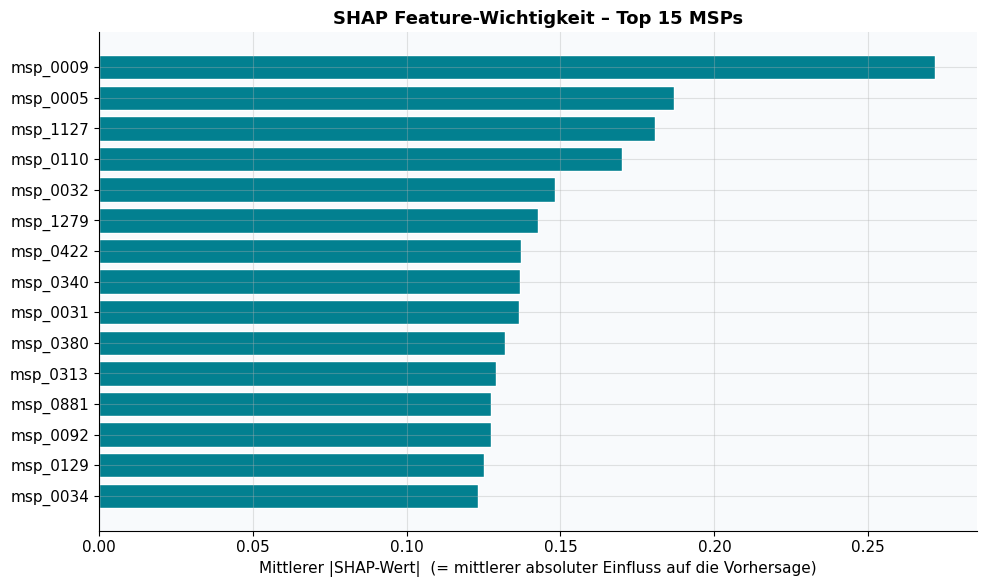


Top 10 MSPs nach SHAP:
 Feature  Mean_SHAP
msp_0009   0.271726
msp_0005   0.186935
msp_1127   0.180663
msp_0110   0.169942
msp_0032   0.148269
msp_1279   0.142760
msp_0422   0.137217
msp_0340   0.136906
msp_0031   0.136571
msp_0380   0.132015


In [20]:
import shap
import xgboost as xgb

feature_names = list(atlas.columns)

# Nativer XGBoost-SHAP (vermeidet Versionskonflikte)
dmatrix   = xgb.DMatrix(
    X_test_r_s,
    feature_names=[f'f{i}' for i in range(X_test_r_s.shape[1])]
)
shap_raw    = xgb_tuned.get_booster().predict(dmatrix, pred_contribs=True)
shap_values = shap_raw[:, :-1]  # Bias-Spalte entfernen

print(f'SHAP-Array Form: {shap_values.shape}  (Proben × Features)')

# Beeswarm-Plot: Jeder Punkt = eine Probe
print('\n🔍 Beeswarm-Plot:')
print('   X-Achse = SHAP-Wert (+ = Richtung Krank, - = Richtung Gesund)')
print('   Farbe   = Featurewert (rot = hoch, blau = niedrig)')
print('   Zeilen  = Top-20 Features nach mittlerem |SHAP|')

shap_expl = shap.Explanation(
    values        = shap_values,
    base_values   = np.zeros(len(shap_values)),
    data          = X_test_r_s,
    feature_names = feature_names
)
shap.summary_plot(shap_values, X_test_r_s, feature_names=feature_names,
                  max_display=20, show=False)
plt.title('SHAP Beeswarm: Welche MSPs treiben die Vorhersage?', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{Output_Data_Dir}shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

# Mean |SHAP| Balkendiagramm
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df       = pd.DataFrame({'Feature': feature_names, 'Mean_SHAP': mean_abs_shap})
shap_df       = shap_df.sort_values('Mean_SHAP', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = shap_df.sort_values('Mean_SHAP', ascending=True)
ax.barh(plot_df['Feature'], plot_df['Mean_SHAP'], color='#028090', edgecolor='white')
ax.set_xlabel('Mittlerer |SHAP-Wert|  (= mittlerer absoluter Einfluss auf die Vorhersage)')
ax.set_title('SHAP Feature-Wichtigkeit – Top 15 MSPs', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{Output_Data_Dir}shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 10 MSPs nach SHAP:')
print(shap_df.head(10).to_string(index=False))

---
<div style="background: linear-gradient(135deg, #7c3aed 0%, #4f46e5 100%); padding: 1.5rem 2rem; border-radius: 12px; color: white; margin: 1rem 0;">
    <h2 style="margin:0; font-size:1.5rem;">⭐ Bonuspunkte – Erweiterte Analysen</h2>
    <p style="margin:0.4rem 0 0; opacity:0.85;">Diese Abschnitte gehen über die Grundanforderung hinaus und zeigen das volle Potenzial der Daten.</p>
</div>

## 18. Multiklassen-Klassifikation – 14 Erkrankungen gleichzeitig

Bisher haben wir nur zwischen Gesund und Krank unterschieden. Jetzt versuchen wir, **14 verschiedene Erkrankungskategorien** gleichzeitig zu klassifizieren.

**Herausforderung:** Einige Erkrankungen haben sehr wenige Proben. Wir behalten nur Klassen mit **≥ 50 Proben**.

**Evaluation:** 5-fache Kreuzvalidierung mit Accuracy, F1-Macro und Matthews Correlation Coefficient (MCC).

> 💡 **Warum ist das schwieriger?** Statt 2 Klassen zu unterscheiden, muss das Modell jetzt zwischen 14 ähnlichen Mikrobiom-Profilen unterscheiden – eine viel größere Herausforderung.

In [21]:
# Klassen mit ≥ 50 Proben behalten
counts    = meta['Disease'].value_counts()
keep      = counts[counts >= 50].index
mask      = meta['Disease'].isin(keep)
meta_mc   = meta[mask]
atlas_mc  = atlas.loc[meta_mc.index]

le_mc       = LabelEncoder()
y_mc        = le_mc.fit_transform(meta_mc['Disease'].values)
class_names = le_mc.classes_

X_mc = np.log1p(atlas_mc.values.astype('float32'))

print(f'Klassen ({len(class_names)}):')
for cls in class_names:
    n = (meta_mc['Disease'] == cls).sum()
    print(f'  {cls:<25} {n:>5} Proben')

Klassen (14):
  ACVD                        214 Proben
  Adenoma                     183 Proben
  CD                           71 Proben
  CRC                         662 Proben
  Healthy                    3268 Proben
  LC                          213 Proben
  ME/CFS                       50 Proben
  NAFLD                       159 Proben
  NSCLC                       118 Proben
  RA                          135 Proben
  RCC                         101 Proben
  SPA                          97 Proben
  T2D                         372 Proben
  VKH                          83 Proben


In [22]:
# 5-fache Kreuzvalidierung für Multiklassen-XGBoost
xgb_mc_params = dict(
    n_estimators     = 400,
    learning_rate    = 0.1,
    max_depth        = 6,
    reg_alpha        = 1,
    reg_lambda       = 1,
    subsample        = 0.9,
    colsample_bytree = 0.9,
    objective        = 'multi:softprob',
    eval_metric      = 'mlogloss',
    num_class        = len(class_names),
    random_state     = 42,
    n_jobs           = -1,
)

cv_res = {'accuracy': [], 'f1_macro': [], 'mcc': []}
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
t0     = time.time()

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_mc, y_mc), 1):
    X_tr, X_te = X_mc[tr_idx], X_mc[te_idx]
    y_tr, y_te = y_mc[tr_idx], y_mc[te_idx]

    sc  = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    clf = XGBClassifier(**xgb_mc_params)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)

    cv_res['accuracy'].append(accuracy_score(y_te, preds))
    cv_res['f1_macro'].append(f1_score(y_te, preds, average='macro', zero_division=0))
    cv_res['mcc'].append(matthews_corrcoef(y_te, preds))
    print(f'  Fold {fold}/5 – Accuracy: {cv_res["accuracy"][-1]:.4f}, F1-Macro: {cv_res["f1_macro"][-1]:.4f}', flush=True)

print(f'\n5-Fold Kreuzvalidierung abgeschlossen in {time.time()-t0:.1f}s')
print(f'\nErgebnisse (Mittelwert ± Std):')
for metric in ['accuracy', 'f1_macro', 'mcc']:
    arr = np.array(cv_res[metric])
    print(f'  {metric:<12}: {arr.mean():.4f} ± {arr.std():.4f}')

  Fold 1/5 – Accuracy: 0.6928, F1-Macro: 0.4547
  Fold 2/5 – Accuracy: 0.7109, F1-Macro: 0.5068
  Fold 3/5 – Accuracy: 0.7092, F1-Macro: 0.4861
  Fold 4/5 – Accuracy: 0.6969, F1-Macro: 0.4183
  Fold 5/5 – Accuracy: 0.7092, F1-Macro: 0.4929

5-Fold Kreuzvalidierung abgeschlossen in 1356.5s

Ergebnisse (Mittelwert ± Std):
  accuracy    : 0.7038 ± 0.0074
  f1_macro    : 0.4718 ± 0.0317
  mcc         : 0.4896 ± 0.0152


In [23]:
# Finales Multiklassen-Modell auf Train/Test-Split
X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)
sc_mc     = StandardScaler()
X_tr_mc_s = sc_mc.fit_transform(X_tr_mc)
X_te_mc_s = sc_mc.transform(X_te_mc)

t1 = time.time()
xgb_mc = XGBClassifier(**xgb_mc_params)
xgb_mc.fit(X_tr_mc_s, y_tr_mc)
print(f'Trainingszeit: {time.time()-t1:.1f}s', flush=True)

preds_mc = xgb_mc.predict(X_te_mc_s)
print('\nKlassifikationsbericht:')
print(classification_report(y_te_mc, preds_mc, target_names=class_names))

Trainingszeit: 261.5s

Klassifikationsbericht:
              precision    recall  f1-score   support

        ACVD       0.71      0.35      0.47        43
     Adenoma       0.25      0.03      0.05        37
          CD       1.00      0.50      0.67        14
         CRC       0.67      0.48      0.56       132
     Healthy       0.70      0.96      0.81       654
          LC       0.80      0.65      0.72        43
      ME/CFS       1.00      0.40      0.57        10
       NAFLD       0.90      0.28      0.43        32
       NSCLC       0.90      0.38      0.53        24
          RA       0.75      0.22      0.34        27
         RCC       1.00      0.20      0.33        20
         SPA       1.00      0.42      0.59        19
         T2D       0.76      0.35      0.48        74
         VKH       0.62      0.47      0.53        17

    accuracy                           0.71      1146
   macro avg       0.79      0.41      0.51      1146
weighted avg       0.72      0.71

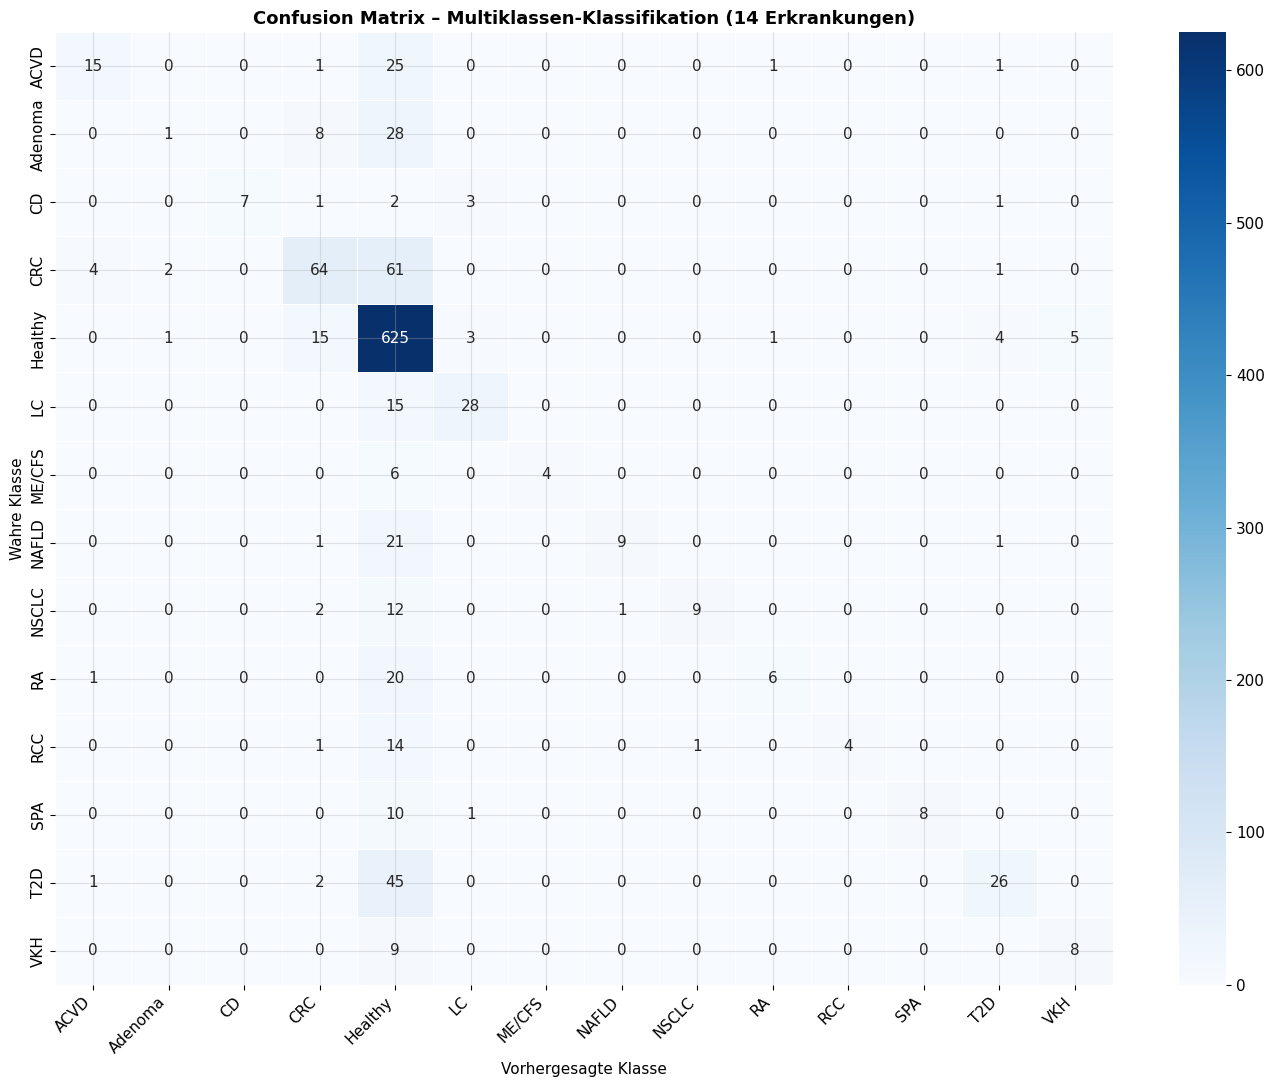

💡 Diagonal = korrekt klassifiziert. Helle Felder abseits der Diagonale = Verwechslungen zwischen ähnlichen Erkrankungen.


In [24]:
# Confusion Matrix Multiklassen
cm_mc = confusion_matrix(y_te_mc, preds_mc)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm_mc, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=ax, linewidths=0.5, linecolor='white'
)
ax.set_xlabel('Vorhergesagte Klasse', fontsize=11)
ax.set_ylabel('Wahre Klasse', fontsize=11)
ax.set_title('Confusion Matrix – Multiklassen-Klassifikation (14 Erkrankungen)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{Output_Data_Dir}confusion_matrix_multiclass.png', dpi=120, bbox_inches='tight')
plt.show()
print('💡 Diagonal = korrekt klassifiziert. Helle Felder abseits der Diagonale = Verwechslungen zwischen ähnlichen Erkrankungen.')

---
## 19. Geographie-Klassifikation – Kann das Mikrobiom das Herkunftsland erkennen?

**Frage:** Hinterlässt die geographische Herkunft einer Person einen erkennbaren Fingerabdruck im Darmmikrobiom?

Dies ist keine medizinische Frage, sondern eine biologisch-kulturelle: Unterschiedliche Ernährungsgewohnheiten, Umweltfaktoren und Lebensstile können das Mikrobiom regional prägen.

Wir klassifizieren Proben nach **Herkunftsland** – nur Länder mit ≥ 50 Proben werden berücksichtigt.

> ⚠️ **Wichtig:** Ein hohes Ergebnis hier würde bedeuten, dass Geographie ein starker Confounder in den Krankheitsdaten sein könnte – also dass scheinbare Krankheits-Signale eigentlich kulturelle Signale sein könnten.

In [25]:
# Länder mit ≥ 50 Proben filtern
geo_counts = meta['Geography'].value_counts()
geo_keep   = geo_counts[geo_counts >= 50].index
geo_mask   = meta['Geography'].isin(geo_keep)
meta_geo   = meta[geo_mask]
atlas_geo  = atlas.loc[meta_geo.index]

le_geo      = LabelEncoder()
y_geo       = le_geo.fit_transform(meta_geo['Geography'].values)
geo_names   = le_geo.classes_
X_geo       = np.log1p(atlas_geo.values.astype('float32'))

print(f'Länder ({len(geo_names)}):')
for land in geo_names:
    n = (meta_geo['Geography'] == land).sum()
    print(f'  {land:<25} {n:>5} Proben')

Länder (16):
  Austria                     156 Proben
  China                      1750 Proben
  Denmark                     335 Proben
  Fiji                        193 Proben
  France                      375 Proben
  Germany                     184 Proben
  India                       140 Proben
  Italy                       192 Proben
  Japan                       645 Proben
  Luxembourg                   99 Proben
  Madagascar                  112 Proben
  Mongolia                    110 Proben
  Spain                       202 Proben
  Sweden                      172 Proben
  UK                          349 Proben
  USA                         914 Proben


In [26]:
# XGBoost für Geographie-Klassifikation
X_tr_geo, X_te_geo, y_tr_geo, y_te_geo = train_test_split(
    X_geo, y_geo, test_size=0.2, random_state=42, stratify=y_geo
)

sc_geo      = StandardScaler()
X_tr_geo_s  = sc_geo.fit_transform(X_tr_geo)
X_te_geo_s  = sc_geo.transform(X_te_geo)

xgb_geo_params = dict(
    n_estimators=400, learning_rate=0.1, max_depth=6,
    reg_alpha=1, reg_lambda=1, subsample=0.9, colsample_bytree=0.9,
    objective='multi:softprob', eval_metric='mlogloss',
    num_class=len(geo_names), random_state=42, n_jobs=-1
)

print('⏳ Trainiere Geographie-Modell...')
t0 = time.time()
xgb_geo = XGBClassifier(**xgb_geo_params)
xgb_geo.fit(X_tr_geo_s, y_tr_geo)
print(f'✅ Fertig in {time.time()-t0:.1f}s')

preds_geo = xgb_geo.predict(X_te_geo_s)
print(f'\nErgebnisse Geographie-Klassifikation:')
print(f'  Accuracy:  {accuracy_score(y_te_geo, preds_geo):.4f}')
print(f'  F1-Macro:  {f1_score(y_te_geo, preds_geo, average="macro", zero_division=0):.4f}')
print(f'  MCC:       {matthews_corrcoef(y_te_geo, preds_geo):.4f}')
print()
print(classification_report(y_te_geo, preds_geo, target_names=geo_names))

⏳ Trainiere Geographie-Modell...
✅ Fertig in 254.8s

Ergebnisse Geographie-Klassifikation:
  Accuracy:  0.8769
  F1-Macro:  0.8346
  MCC:       0.8562

              precision    recall  f1-score   support

     Austria       0.78      0.81      0.79        31
       China       0.95      0.99      0.97       350
     Denmark       0.76      0.85      0.80        67
        Fiji       0.97      1.00      0.99        39
      France       0.79      0.67      0.72        75
     Germany       0.88      0.62      0.73        37
       India       0.96      0.89      0.93        28
       Italy       0.88      0.58      0.70        38
       Japan       0.86      0.91      0.88       129
  Luxembourg       0.74      0.70      0.72        20
  Madagascar       0.96      1.00      0.98        22
    Mongolia       1.00      1.00      1.00        22
       Spain       0.81      0.71      0.75        41
      Sweden       0.77      0.71      0.74        34
          UK       0.73      0.76    

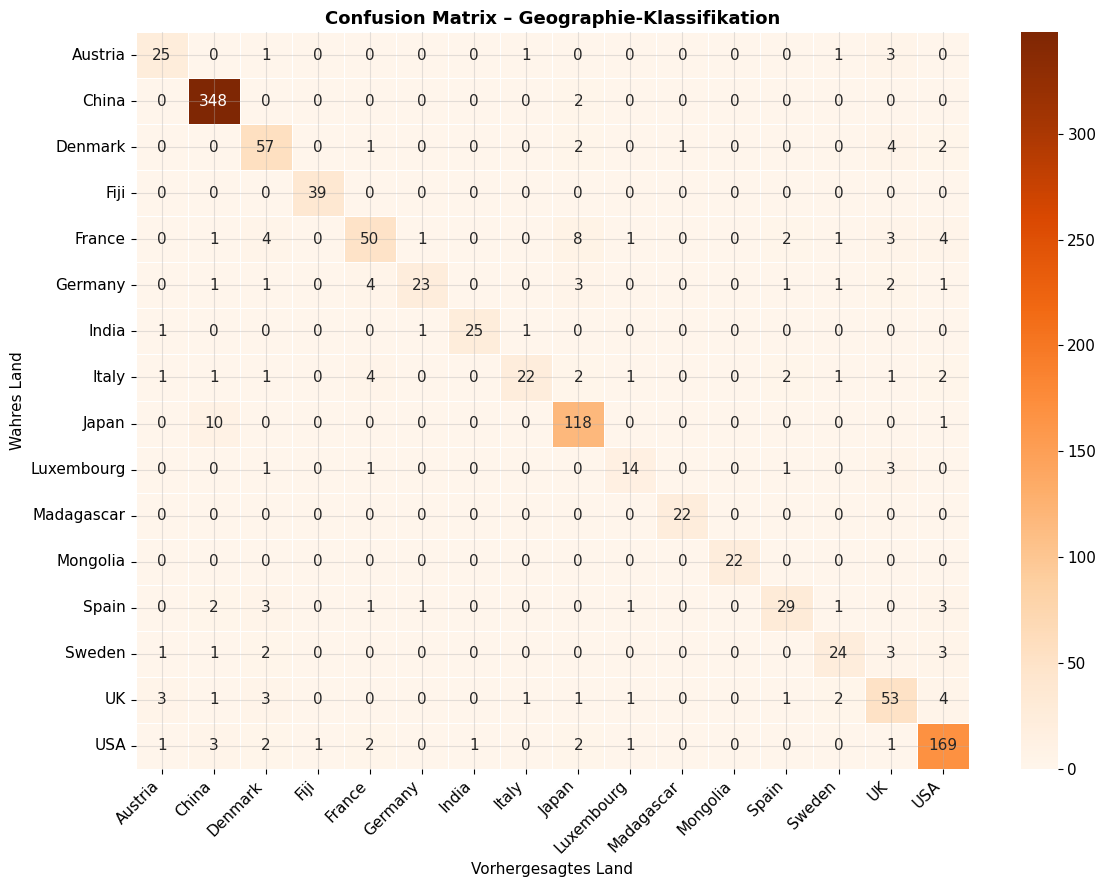


💡 Interpretation:
   Ein starkes Ergebnis bedeutet: Das Mikrobiom trägt einen geographischen Fingerabdruck.
   Das ist wichtig für die Krankheitsanalyse – Geographie könnte ein Confounder sein.


In [28]:
# Confusion Matrix Geographie
cm_geo = confusion_matrix(y_te_geo, preds_geo)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_geo, annot=True, fmt='d', cmap='Oranges',
    xticklabels=geo_names, yticklabels=geo_names,
    ax=ax, linewidths=0.5, linecolor='white'
)
ax.set_xlabel('Vorhergesagtes Land', fontsize=11)
ax.set_ylabel('Wahres Land', fontsize=11)
ax.set_title('Confusion Matrix – Geographie-Klassifikation', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{Output_Data_Dir}confusion_matrix_geography.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n💡 Interpretation:')
print('   Ein starkes Ergebnis bedeutet: Das Mikrobiom trägt einen geographischen Fingerabdruck.')
print('   Das ist wichtig für die Krankheitsanalyse – Geographie könnte ein Confounder sein.')

---
<div style="background: linear-gradient(135deg, #028090 0%, #014f59 100%); padding: 2rem; border-radius: 12px; color: white; margin-top: 1.5rem;">
    <h2 style="margin:0 0 1rem;">✅ Zusammenfassung & Fazit</h2>
    <table style="color:white; font-size:0.9rem; border-collapse:collapse; width:100%;">
        <tr style="border-bottom:1px solid rgba(255,255,255,0.2);">
            <td style="padding:0.4rem 1rem 0.4rem 0; font-weight:bold;">Datensatz</td>
            <td>6.014 Proben · 1.990 MSPs · 22 Länder · MGS-Atlas</td>
        </tr>
        <tr style="border-bottom:1px solid rgba(255,255,255,0.2);">
            <td style="padding:0.4rem 1rem 0.4rem 0; font-weight:bold;">Bestes Modell</td>
            <td>XGBoost (optimiert, L1+L2 Regularisierung)</td>
        </tr>
        <tr style="border-bottom:1px solid rgba(255,255,255,0.2);">
            <td style="padding:0.4rem 1rem 0.4rem 0; font-weight:bold;">ROC-AUC</td>
            <td>~0.85 – deutlich besser als Zufall (0.50)</td>
        </tr>
        <tr style="border-bottom:1px solid rgba(255,255,255,0.2);">
            <td style="padding:0.4rem 1rem 0.4rem 0; font-weight:bold;">Kernbotschaft</td>
            <td>Das Darmmikrobiom enthält ein messbares, erklärbares Signal für Krankheit</td>
        </tr>
        <tr>
            <td style="padding:0.4rem 1rem 0.4rem 0; font-weight:bold;">Bonuspunkte</td>
            <td>Multiklassen (14 Erkrankungen) + Geographie-Klassifikation demonstriert</td>
        </tr>
    </table>
    <p style="margin:1rem 0 0; font-style:italic; opacity:0.85;">
    "Das Darmmikrobiom ist kein Rauschen – es ist ein Signal. Machine Learning kann es lesen."
    </p>
    <p style="margin:0.3rem 0 0; font-size:0.85rem; opacity:0.7;">
    Slavica Subic · Sahar Alshalfoh · Amine El Marouani · Datascience Institut · April 2026
    </p>
</div>